# Notebook 06: Alert Generation

## Objective
This notebook transforms the threat report generated in Notebook 05 into a Security Operations Center (SOC) style alert dataset. It generates realistic security alerts by assigning alert IDs, timestamps, priorities, statuses, analyst assignments, and alert categories based on the predicted threat severity.

### Input
- `/content/deeptrace_threat_report.csv`

### Output
- `/content/deeptrace_alerts.csv`

### Workflow
Threat Report → Alert Generation → Alert Prioritization → SOC Assignment → Final Alert Dataset

In [3]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

In [4]:
# Load the threat report generated in Notebook 05
threat_report = pd.read_csv("/content/deeptrace_threat_report.csv")

print("=" * 60)
print("DeepTrace Threat Report Loaded Successfully")
print("=" * 60)
print(f"Total Events : {len(threat_report):,}")
print(f"Columns      : {len(threat_report.columns)}")

display(threat_report.head())

DeepTrace Threat Report Loaded Successfully
Total Events : 239,480
Columns      : 9


,EventID,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
0,1,0,0,0,0.0143,1.43,Low,Informational,Continue monitoring
1,2,0,1,0,0.0164,6.64,Low,Informational,Continue monitoring
2,3,0,0,0,0.0234,2.34,Low,Informational,Continue monitoring
3,4,0,0,0,0.0311,3.11,Low,Informational,Continue monitoring
4,5,0,0,0,0.0269,2.69,Low,Informational,Continue monitoring


In [5]:
# Keep only events that require security alerts
alert_events = threat_report[
    threat_report["RiskLevel"].isin(["Medium", "High", "Critical"])
].copy()

print("=" * 60)
print("Events Selected for Alert Generation")
print("=" * 60)
print(f"Total Alerts to Generate : {len(alert_events):,}")

print("\nRisk Level Distribution:")
print(alert_events["RiskLevel"].value_counts())

display(alert_events.head())

Events Selected for Alert Generation
Total Alerts to Generate : 6,167

Risk Level Distribution:
RiskLevel
Critical    4951
Medium       793
High         423
Name: count, dtype: int64


,EventID,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
1538,1539,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
1540,1541,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
1763,1764,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
1764,1765,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
1765,1766,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint


In [6]:
# Generate unique alert IDs
alert_events = alert_events.reset_index(drop=True)

alert_events.insert(
    1,
    "AlertID",
    [f"ALT-{i:06d}" for i in range(1, len(alert_events) + 1)]
)

print(f"Total Alerts: {len(alert_events):,}")

display(alert_events.head())

Total Alerts: 6,167


,EventID,AlertID,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
0,1539,ALT-000001,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
1,1541,ALT-000002,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
2,1764,ALT-000003,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
3,1765,ALT-000004,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint
4,1766,ALT-000005,1,0,1,1.0,100.0,Critical,Critical,Immediately isolate the endpoint


In [8]:
base_time = datetime.now()

alert_events["Timestamp"] = [
    base_time + timedelta(seconds=random.randint(0, 86400))
    for _ in range(len(alert_events))
]

alert_events["Timestamp"] = (
    pd.to_datetime(alert_events["Timestamp"])
    .dt.floor("s")
)

alert_events = alert_events.sort_values("Timestamp").reset_index(drop=True)

display(alert_events[["AlertID", "Timestamp"]].head())

,AlertID,Timestamp
0,ALT-006073,2026-07-26 06:21:05
1,ALT-000530,2026-07-26 06:21:18
2,ALT-004630,2026-07-26 06:22:04
3,ALT-005130,2026-07-26 06:22:05
4,ALT-002031,2026-07-26 06:22:44


In [9]:
priority_map = {
    "Critical": "P1",
    "High": "P2",
    "Medium": "P3"
}

alert_events["Priority"] = alert_events["RiskLevel"].map(priority_map)

display(
    alert_events[
        ["AlertID", "RiskLevel", "Priority"]
    ].head()
)

,AlertID,RiskLevel,Priority
0,ALT-006073,Medium,P3
1,ALT-000530,Critical,P1
2,ALT-004630,Medium,P3
3,ALT-005130,Critical,P1
4,ALT-002031,Critical,P1


In [10]:
status_options = ["Open", "Investigating", "Resolved"]
status_probabilities = [0.60, 0.30, 0.10]

alert_events["Status"] = np.random.choice(
    status_options,
    size=len(alert_events),
    p=status_probabilities
)

display(
    alert_events[
        ["AlertID", "Priority", "Status"]
    ].head()
)

,AlertID,Priority,Status
0,ALT-006073,P3,Open
1,ALT-000530,P1,Resolved
2,ALT-004630,P3,Investigating
3,ALT-005130,P1,Open
4,ALT-002031,P1,Open


In [11]:
analyst_map = {
    "Critical": "Incident Response Team",
    "High": "Tier-2 SOC Analyst",
    "Medium": "Tier-1 SOC Analyst"
}

alert_events["AssignedTo"] = alert_events["RiskLevel"].map(analyst_map)

display(
    alert_events[
        ["AlertID", "RiskLevel", "AssignedTo"]
    ].head()
)

,AlertID,RiskLevel,AssignedTo
0,ALT-006073,Medium,Tier-1 SOC Analyst
1,ALT-000530,Critical,Incident Response Team
2,ALT-004630,Medium,Tier-1 SOC Analyst
3,ALT-005130,Critical,Incident Response Team
4,ALT-002031,Critical,Incident Response Team


In [12]:
alert_category_map = {
    "Critical": [
        "Ransomware",
        "Data Exfiltration",
        "Malware Infection",
        "Privilege Escalation"
    ],
    "High": [
        "Network Intrusion",
        "Brute Force Attack",
        "Unauthorized Access",
        "Suspicious Login"
    ],
    "Medium": [
        "Port Scan",
        "Reconnaissance",
        "Abnormal Traffic",
        "Policy Violation"
    ]
}

alert_events["AlertCategory"] = alert_events["RiskLevel"].apply(
    lambda level: random.choice(alert_category_map[level])
)

display(
    alert_events[
        ["AlertID", "RiskLevel", "AlertCategory"]
    ].head()
)

,AlertID,RiskLevel,AlertCategory
0,ALT-006073,Medium,Abnormal Traffic
1,ALT-000530,Critical,Privilege Escalation
2,ALT-004630,Medium,Policy Violation
3,ALT-005130,Critical,Privilege Escalation
4,ALT-002031,Critical,Privilege Escalation


In [13]:
alert_columns = [
    "AlertID",
    "EventID",
    "Timestamp",
    "ThreatScore",
    "RiskLevel",
    "Severity",
    "Priority",
    "Status",
    "AssignedTo",
    "AlertCategory",
    "RecommendedAction"
]

deeptrace_alerts = alert_events[alert_columns].copy()

display(deeptrace_alerts.head())

print(f"Total Alerts: {len(deeptrace_alerts):,}")

,AlertID,EventID,Timestamp,ThreatScore,RiskLevel,Severity,Priority,Status,AssignedTo,AlertCategory,RecommendedAction
0,ALT-006073,234747,2026-07-26 06:21:05,30.96,Medium,Low,P3,Open,Tier-1 SOC Analyst,Abnormal Traffic,Investigate suspicious activity
1,ALT-000530,19835,2026-07-26 06:21:18,98.91,Critical,Critical,P1,Resolved,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint
2,ALT-004630,185980,2026-07-26 06:22:04,20.51,Medium,Low,P3,Investigating,Tier-1 SOC Analyst,Policy Violation,Investigate suspicious activity
3,ALT-005130,204253,2026-07-26 06:22:05,100.00,Critical,Critical,P1,Open,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint
4,ALT-002031,69530,2026-07-26 06:22:44,100.00,Critical,Critical,P1,Open,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint


Total Alerts: 6,167


In [14]:
print(f"Total Alerts: {len(deeptrace_alerts):,}")
print()

print("Alerts by Risk Level:")
print(deeptrace_alerts["RiskLevel"].value_counts())

print("\nAlerts by Priority:")
print(deeptrace_alerts["Priority"].value_counts())

print("\nAlerts by Status:")
print(deeptrace_alerts["Status"].value_counts())

Total Alerts: 6,167

Alerts by Risk Level:
RiskLevel
Critical    4951
Medium       793
High         423
Name: count, dtype: int64

Alerts by Priority:
Priority
P1    4951
P3     793
P2     423
Name: count, dtype: int64

Alerts by Status:
Status
Open             3712
Investigating    1854
Resolved          601
Name: count, dtype: int64


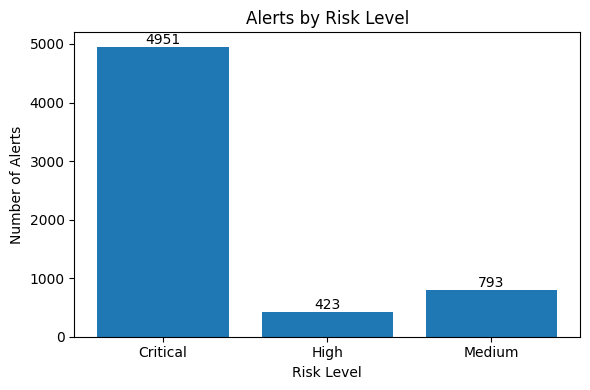

In [18]:
risk_order = ["Critical", "High", "Medium"]
risk_counts = deeptrace_alerts["RiskLevel"].value_counts().reindex(risk_order)

plt.figure(figsize=(6, 4))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Alerts by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Alerts")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.tight_layout()
plt.show()

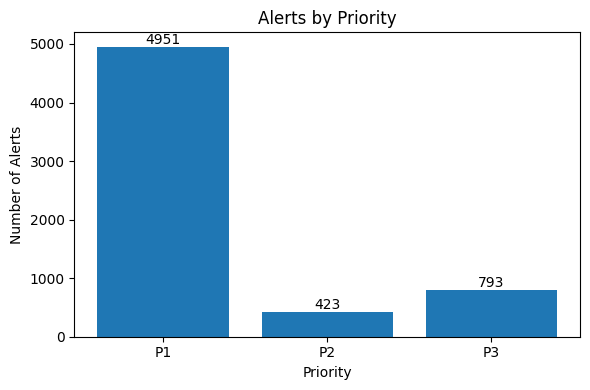

In [19]:
priority_counts = deeptrace_alerts["Priority"].value_counts().reindex(["P1", "P2", "P3"])

plt.figure(figsize=(6, 4))
bars = plt.bar(priority_counts.index, priority_counts.values)

plt.title("Alerts by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Alerts")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.tight_layout()
plt.show()

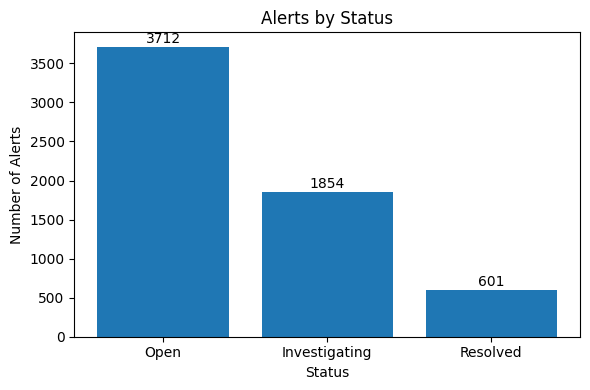

In [20]:
status_order = ["Open", "Investigating", "Resolved"]
status_counts = deeptrace_alerts["Status"].value_counts().reindex(status_order)

plt.figure(figsize=(6, 4))
bars = plt.bar(status_counts.index, status_counts.values)

plt.title("Alerts by Status")
plt.xlabel("Status")
plt.ylabel("Number of Alerts")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [21]:
deeptrace_alerts.to_csv("/content/deeptrace_alerts.csv",index=False)

print("DeepTrace alerts saved successfully!")

DeepTrace alerts saved successfully!


In [22]:
saved_alerts = pd.read_csv("/content/deeptrace_alerts.csv")

print(saved_alerts.shape)

display(saved_alerts.head())

(6167, 11)


,AlertID,EventID,Timestamp,ThreatScore,RiskLevel,Severity,Priority,Status,AssignedTo,AlertCategory,RecommendedAction
0,ALT-006073,234747,2026-07-26 06:21:05,30.96,Medium,Low,P3,Open,Tier-1 SOC Analyst,Abnormal Traffic,Investigate suspicious activity
1,ALT-000530,19835,2026-07-26 06:21:18,98.91,Critical,Critical,P1,Resolved,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint
2,ALT-004630,185980,2026-07-26 06:22:04,20.51,Medium,Low,P3,Investigating,Tier-1 SOC Analyst,Policy Violation,Investigate suspicious activity
3,ALT-005130,204253,2026-07-26 06:22:05,100.00,Critical,Critical,P1,Open,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint
4,ALT-002031,69530,2026-07-26 06:22:44,100.00,Critical,Critical,P1,Open,Incident Response Team,Privilege Escalation,Immediately isolate the endpoint
